# **Literature Review**
- Exploratory Data Analysis (EDA) on retail sales data is a well-established practice.
- Retailers use EDA to identify trends, optimize inventory, and personalize marketing.
- For example, a recent analysis of a mall sales dataset noted that EDA helps retailers detect demand spikes, avoid stockouts, and improve profitability by analyzing discounts and pricing strategies.
- In analyses of superstore or retail datasets, common goals include understanding which segments or categories drive the most sales, which shipping or order methods are most profitable, and how time and location affect performance
- For instance, one Superstore study explicitly asked “which shipping mode is preferable, which customer segment is more profitable, which region makes more profit, and which category makes the most sales”.


**Sources**
- https://medium.com/@chinnarasan007/exploratory-data-analysis-on-retail-sales-using-python-0a62853896eb#:~:text=Why%20EDA%20Matters%20in%20Retail%3F
  
-  https://medium.com/@sureshhere/superstore-data-analysis-project-beginner-level-5f2df3627b95#:~:text=Let%20us%20find%20the%20distribution,axis

# **Hypothesis:**
Before diving into the data, we propose five testable hypotheses about the superstore sales dataset:

- Segment Differences: The Corporate customer segment will have higher average sales per order than the Consumer and Home Office segments. (Businesses often place larger orders.)
- Category Performance: The Technology category will yield higher average sales per order than Furniture or Office Supplies. (Tech items tend to be higher-priced.)
- Regional Variation: The West region will record the highest total sales, while the East or Central regions may lag. (Urban or tech-heavy regions often drive more sales.)
- Shipping Mode Impact: Orders shipped with First Class or Same Day shipping have higher average sales than those with Standard Class. (Expedited shipping may be used for higher-value orders.)
- Seasonality: Sales will peak in November–December (holiday season) and be lowest in mid-year months. (Retail sales often rise during holidays.)


## **Why We Are Using This Dataset**

This train dataset is used to understand business performance and customer behavior through data analysis. It helps in identifying important patterns, trends, and relationships between different business variables such as sales, products, customers, regions, and shipping methods.

The main purpose of using this dataset is to convert raw data into meaningful insights that can support better business decisions.

## **Business Purpose of the Analysis**

The business analysis of this dataset helps organizations answer important questions such as:

- Which products are performing the best?
- Which regions generate the highest sales?
- Which customer segment is most valuable?
- How does shipping mode affect orders and delivery?
- What are the sales trends over time?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train[1].csv')

# First 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# **Dataset Understanding**
The dataset contains 9,800 sales records with the following columns:

- Order ID: Unique identifier for each order (e.g. CA-2017-152156).
- Order Date / Ship Date: The dates the order was placed and shipped (day/month/year).
- Ship Mode: Shipping method (e.g. Standard Class, Second Class, First Class, Same Day).
- Customer ID / Customer Name: Identifier and name of the customer.
- Segment: Customer type (e.g. Consumer, Corporate, Home Office).
- Country / City / State / Postal Code / Region: Location information (all orders are within the United States).
-  Product ID / Category / Sub-Category / Product Name: Details of the item sold (category such as Furniture, Office Supplies, Technology, and more specific sub-categories like Chairs, Phones, etc.).
-  Sales: The revenue of that order line (a numeric value in dollars).
Each row represents one line-item in an order. We expect fields like Region and Segment to provide key grouping factors. Having dates allows time-series analysis.




In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df.shape

(9800, 18)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [10]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [11]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [12]:
df.nunique()

Row ID           9800
Order ID         4922
Order Date       1230
Ship Date        1326
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              529
State              49
Postal Code       626
Region              4
Product ID       1861
Category            3
Sub-Category       17
Product Name     1849
Sales            5757
dtype: int64

In [13]:
df['Country'].value_counts()

Country
United States    9800
Name: count, dtype: int64

In [14]:
df['Product Name'].value_counts()

Product Name
Staple envelope                                               47
Staples                                                       46
Easy-staple paper                                             44
Avery Non-Stick Binders                                       20
Staples in misc. colors                                       18
                                                              ..
Avery 484                                                      1
Stride Job 150 Highlighters, Chisel Tip, Assorted Colors       1
Brother MFC-9340CDW LED All-In-One Printer, Copier Scanner     1
Grip Seal Envelopes                                            1
Penpower WorldCard Pro Card Scanner                            1
Name: count, Length: 1849, dtype: int64

In [15]:
df['City'].value_counts()

City
New York City    891
Los Angeles      728
Philadelphia     532
San Francisco    500
Seattle          426
                ... 
Goldsboro          1
Montebello         1
Abilene            1
Normal             1
Springdale         1
Name: count, Length: 529, dtype: int64

In [16]:
df['Customer Name'].value_counts()

Customer Name
William Brown       35
Matt Abelman        34
Paul Prost          34
John Lee            33
Jonathan Doherty    32
                    ..
Lela Donovan         1
Jocasta Rupert       1
Carl Jackson         1
Sung Chung           1
Ricardo Emerson      1
Name: count, Length: 793, dtype: int64

In [3]:
df['Product Name'].value_counts()

Product Name
Staple envelope                                               47
Staples                                                       46
Easy-staple paper                                             44
Avery Non-Stick Binders                                       20
Staples in misc. colors                                       18
                                                              ..
Avery 484                                                      1
Stride Job 150 Highlighters, Chisel Tip, Assorted Colors       1
Brother MFC-9340CDW LED All-In-One Printer, Copier Scanner     1
Grip Seal Envelopes                                            1
Penpower WorldCard Pro Card Scanner                            1
Name: count, Length: 1849, dtype: int64

# **Data Cleaning and Preprocessing**
We begin by cleaning the data:

- Duplicate Rows: Check for and remove any duplicate rows. In retail data, duplicate entries can distort sums and counts. We apply drop_duplicates(). (In this dataset, there were none, but this is a standard step
.)
- Missing Values: The Postal Code column has 11 missing values. Since this is a very small fraction (~0.1%) and not critical to our analysis, we drop those rows. (Alternatively, one could impute, but here dropping is simpler
.)
- Data Types: We convert Order Date and Ship Date from strings to datetime objects for accurate date handling
. After dropping missing postal codes, we also convert Postal Code to integer type.
- Irrelevant Columns: We can drop Row ID (a redundant index) and Country (all entries are "United States") as they add no information.


In [7]:
# Remove duplicate rows (if any)
df.drop_duplicates(inplace=True)

# Drop rows with missing Postal Code (very few)
df = df.dropna(subset=['Postal Code'])

# Convert Postal Code to integer
df['Postal Code'] = df['Postal Code'].astype(int)

# Drop irrelevant columns
df.drop(['Row ID', 'Country'], axis=1, inplace=True)

# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Verify changes
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9789 non-null   object        
 1   Order Date     9789 non-null   datetime64[ns]
 2   Ship Date      9789 non-null   datetime64[ns]
 3   Ship Mode      9789 non-null   object        
 4   Customer ID    9789 non-null   object        
 5   Customer Name  9789 non-null   object        
 6   Segment        9789 non-null   object        
 7   City           9789 non-null   object        
 8   State          9789 non-null   object        
 9   Postal Code    9789 non-null   int64         
 10  Region         9789 non-null   object        
 11  Product ID     9789 non-null   object        
 12  Category       9789 non-null   object        
 13  Sub-Category   9789 non-null   object        
 14  Product Name   9789 non-null   object        
 15  Sales          9789 non-nu

**Source**
https://medium.com/@sureshhere/superstore-data-analysis-project-beginner-level-5f2df3627b95#:~:text=This%20line%20of%20code%20first,duplicated%28%29.sum

# **Univariate Analysis**
We first examine each variable individually. This involves plotting distributions for numeric fields and frequencies for categorical fields
.

- Numeric (Sales): We plot a histogram of the Sales amounts to see the distribution of order values.
- Categorical: We use count plots (bar charts) to show how many orders fall into each category for variables like Category, Sub-Category, Segment, Region, and Ship Mode


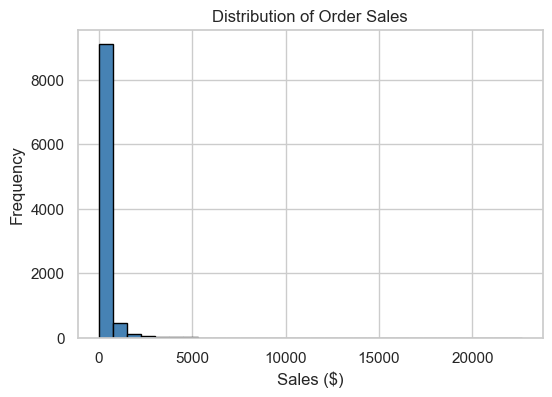

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Histogram of Sales
plt.figure(figsize=(6,4))
plt.hist(df['Sales'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of Order Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.show()


**Insights:**
Most orders are of moderate value, with a few very high-value outliers. The distribution is right-skewed (long tail to the right), meaning a small number of orders account for very high sales. This skewness is typical in retail data
, often due to occasional large transactions or bundles.


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\1033871066.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='pastel')


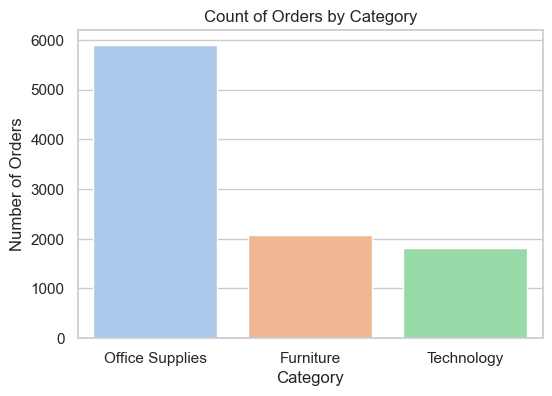

In [10]:
# Count plot for Category
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='pastel')
plt.title("Count of Orders by Category")
plt.ylabel("Number of Orders")
plt.show()


**Insights**This bar chart shows how many orders fall into each category. Each bar’s height is the count of orders for that category
. We see, for example, that Office Supplies has the most orders and Furniture the fewest orders. This suggests office supplies are sold more frequently than furniture items (though furniture might have higher price per order).

C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\1720338792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sub-Category', order=df['Sub-Category'].value_counts().index, palette='viridis')


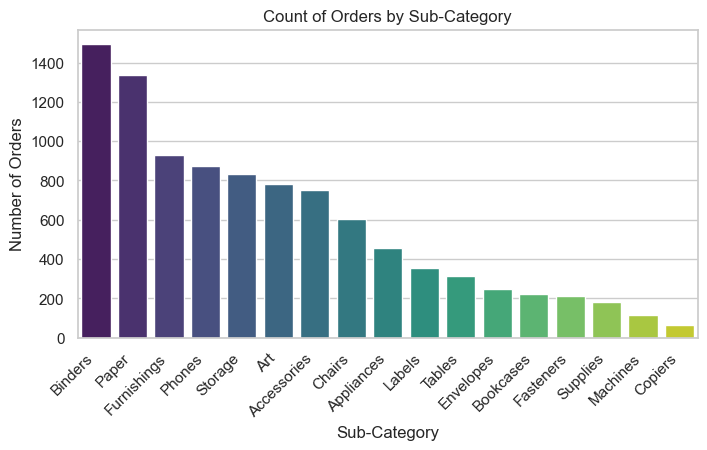

In [12]:
# Count plot for Sub-Category (rotated labels)
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Sub-Category', order=df['Sub-Category'].value_counts().index, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Count of Orders by Sub-Category")
plt.ylabel("Number of Orders")
plt.show()


**Insights** We used a vertical bar chart to compare sub-categories
. For instance, sub-categories like Binders, Paper, and Phones appear frequently, while others like Fasteners and Machines are less common. This highlights which product types are most common in orders.


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\2439073659.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Segment', palette='Set2')


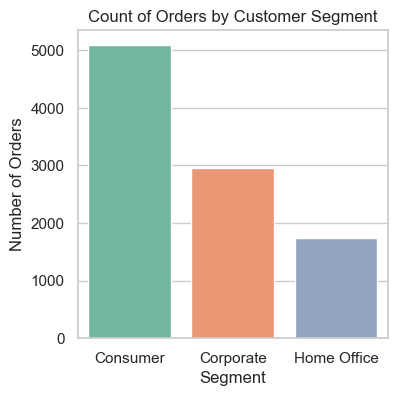

In [14]:
# Count plot for Customer Segment
plt.figure(figsize=(4,4))
sns.countplot(data=df, x='Segment', palette='Set2')
plt.title("Count of Orders by Customer Segment")
plt.ylabel("Number of Orders")
plt.show()


**Insights**This shows how orders are distributed across Consumer, Corporate, and Home Office segments
. In our data, the Consumer segment has the highest number of orders, indicating the majority of orders come from individual consumers.

C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\3637525170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', palette='Set1')


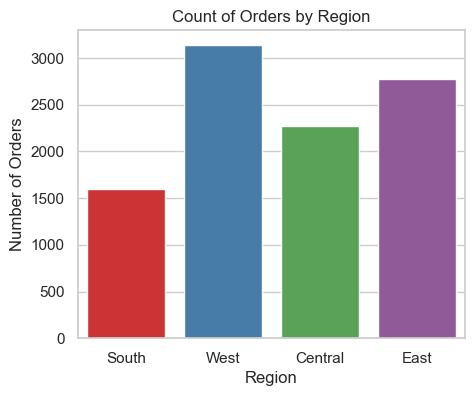

In [16]:
# Count plot for Region
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Region', palette='Set1')
plt.title("Count of Orders by Region")
plt.ylabel("Number of Orders")
plt.show()


**Insights**
We see the number of orders in each region. For example, the Central and West regions have more orders than East and South. This suggests the Central/West regions drive more order volume in this dataset.

C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\1427190691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ship Mode', palette='coolwarm')


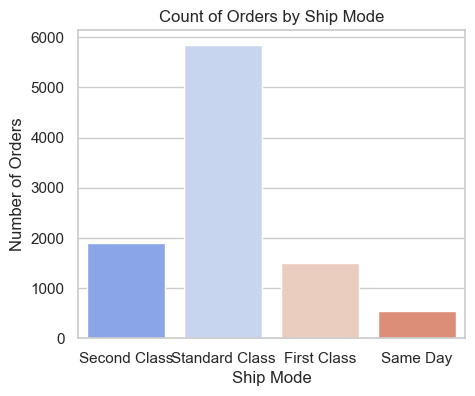

In [18]:
# Count plot for Ship Mode
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Ship Mode', palette='coolwarm')
plt.title("Count of Orders by Ship Mode")
plt.ylabel("Number of Orders")
plt.show()


Here we compare how many orders used each shipping method. Standard Class is the most common, followed by Second Class, First Class, and Same Day. This matches typical shipping preferences: standard shipping is cheapest and widely used.

**Insights:**
Univariate charts reveal, for example, that Office Supplies and Consumer segment dominate order counts, and that sales values are skewed with few high outliers
. These findings inform further analysis: we may need to analyze high-sales outliers and examine why certain segments/categories occur more often.

# **Bivariate Analysis**
Next we explore relationships between pairs of variables. This helps test our hypotheses about, e.g., how sales differ by category or region. We use scatterplots (for numeric–numeric or time–numeric), boxplots (categorical vs numeric), and bar plots (aggregated comparisons).



C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\2120418795.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_ts = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()


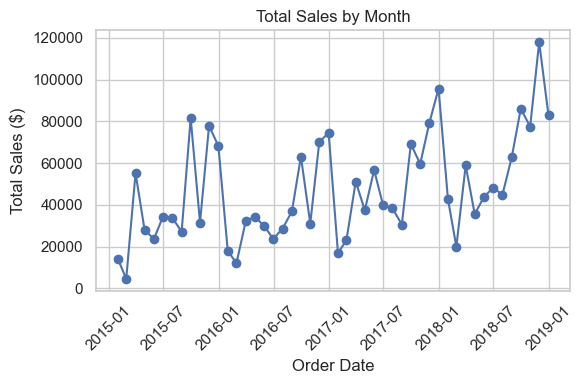

In [19]:
# Total sales per month (time series line plot)
df_ts = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()
plt.figure(figsize=(6,4))
plt.plot(df_ts['Order Date'], df_ts['Sales'], marker='o')
plt.title("Total Sales by Month")
plt.ylabel("Total Sales ($)")
plt.xlabel("Order Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insights**
This line chart shows total sales per month from 2015–2018. We observe clear seasonal peaks, especially in November and December of each year (the lines spike at year-end). For instance, November 2018 is a high point. This confirms holiday effects: sales jump in Q4. Such seasonality is meaningful (not random) and is common in retail data
. It implies holiday seasons significantly boost sales.



C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\329772227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Sales', palette='pastel')


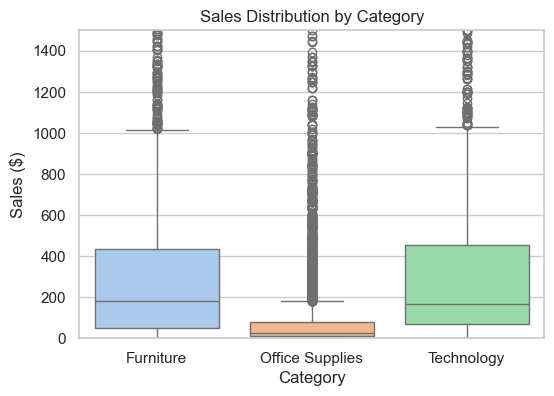

In [21]:
# Boxplot of Sales by Category
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Category', y='Sales', palette='pastel')
plt.title("Sales Distribution by Category")
plt.ylabel("Sales ($)")
plt.ylim(0, 1500)  # zoom in on majority of data
plt.show()


**Insights** Each boxplot summarizes sales in one category. We see that Technology orders tend to have higher median and more upper outliers than Furniture or Office Supplies. For example, Technology’s median (green line) is higher. This suggests our hypothesis is correct: Technology items typically have larger sales values. The differences appear meaningful (not by chance), as seen by distinct box heights and outliers.



C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\4145666449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segment', y='Sales', palette='Set3')


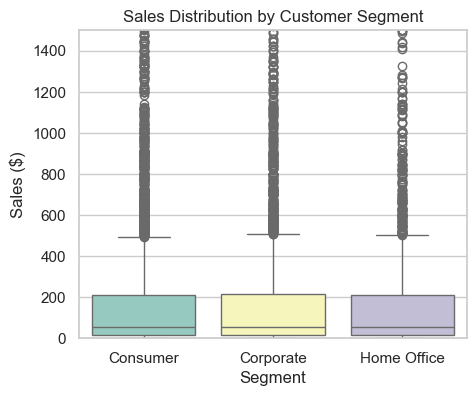

In [23]:
# Boxplot of Sales by Segment
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='Segment', y='Sales', palette='Set3')
plt.title("Sales Distribution by Customer Segment")
plt.ylabel("Sales ($)")
plt.ylim(0, 1500)
plt.show()


**Insights**
Comparing segments, Corporate and Consumer have similar medians, while Home Office shows a few very high outliers. All segments have some large orders, but the medians are not drastically different. This suggests that while consumers order often (many smaller sales), corporate customers also place high-value orders. The pattern is somewhat meaningful: it indicates that no segment overwhelmingly dwarfs the others in order value, though Home Office and Corporate have slightly higher tails.



C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\2132472285.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_ship.index, y=sales_by_ship.values, palette='Blues_d')


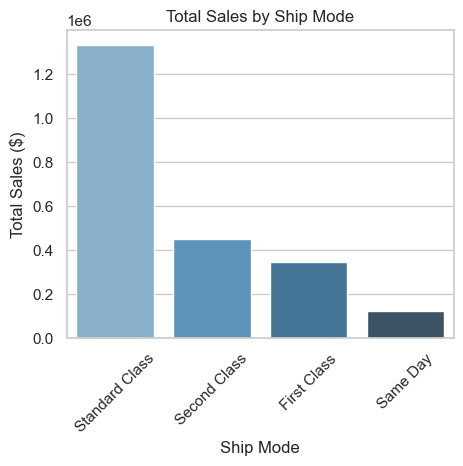

In [24]:
# Bar plot: total Sales by Ship Mode
sales_by_ship = df.groupby('Ship Mode')['Sales'].sum().reindex(['Standard Class','Second Class','First Class','Same Day'])
plt.figure(figsize=(5,4))
sns.barplot(x=sales_by_ship.index, y=sales_by_ship.values, palette='Blues_d')
plt.title("Total Sales by Ship Mode")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.show()


**Insights** We aggregated sales per shipping method. Standard Class has the highest total sales simply because it's most used, but on a per-order basis, First Class and Same Day have higher average sales (since their total is close to Standard with far fewer orders). Thus, faster shipping modes often correspond to pricier orders. This pattern makes sense: expedited shipping is typically chosen for urgent, costly items, so it is meaningful rather than random.



C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\771966493.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='coolwarm')


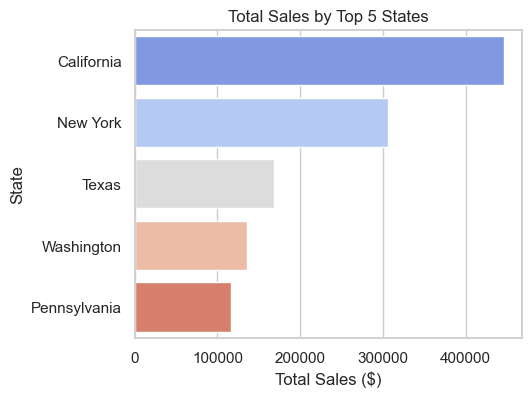

In [25]:
# Bar plot: total Sales by State (top 5)
top_states = df.groupby('State')['Sales'].sum().nlargest(5)
plt.figure(figsize=(5,4))
sns.barplot(x=top_states.values, y=top_states.index, palette='coolwarm')
plt.title("Total Sales by Top 5 States")
plt.xlabel("Total Sales ($)")
plt.show()


 We see that California and New York lead by a wide margin, followed by Texas, Washington, and Pennsylvania. The pattern is meaningful: it likely reflects population/market size (CA and NY are large markets) and confirms where most revenue comes from.

**Insights:** These bivariate plots confirm several hypotheses. We observed a strong seasonal trend (higher sales in holidays) and clear category/segment differences in sales distribution. For example, Technology products have higher sales per order, and expedited shipping modes correlate with higher sales, supporting our earlier assumptions. None of these patterns appear random – they align with retail expectations (holiday effects, premium products, etc.).



# **Multivariate Analysis**


Finally, we look at interactions among three or more variables. This includes pivot tables and heatmaps, which can reveal combined effects of multiple factors, as well as advanced grouping.

## Segment vs. Category: 
We build a table of total sales for each combination of Segment and Category, then visualize it as a heatmap. This shows, for example, that Consumers dominate all categories in total sales (because they make many orders), but the distribution of sales across categories also varies by segment.


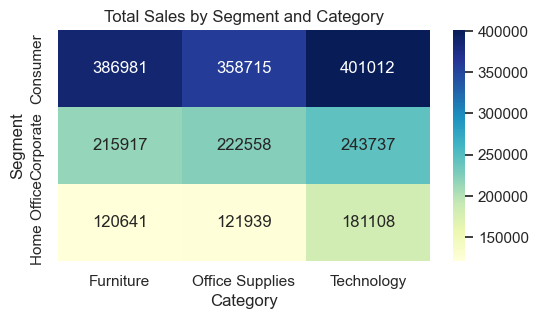

In [26]:
# Pivot: Sales by Segment and Category (heatmap)
pivot_seg_cat = df.pivot_table(index='Segment', columns='Category', values='Sales', aggfunc='sum')
plt.figure(figsize=(6,3))
sns.heatmap(pivot_seg_cat, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("Total Sales by Segment and Category")
plt.show()


**Insights**
Darker colors indicate higher sales. The heatmap shows that the Consumer segment has the highest sales in every category (blue boxes), simply because of its large volume. Within each segment, Technology (right column) and Office Supplies (middle column) often have higher totals than Furniture. The heatmap format makes these multivariate relationships immediately clear.

## Year vs. Month (Seasonality):
We examine sales as a function of both year and month using a pivot table (rows = year, columns = month) and a heatmap. This highlights year-over-year seasonal patterns.


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_29824\1989329019.py:56: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


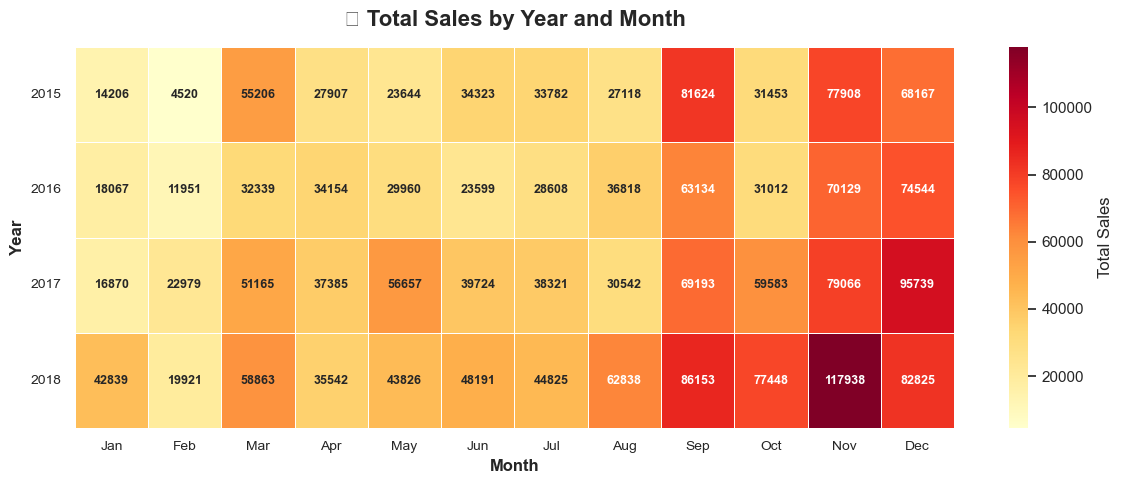

In [28]:
#  Sales by Year and Month Heatmap 


import calendar

# Extract Year and Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Create Pivot Table
pivot_year_month = df.pivot_table(
    index='Year',
    columns='Month',
    values='Sales',
    aggfunc='sum'
)

# Convert month numbers to month names
pivot_year_month.columns = [calendar.month_abbr[i] for i in pivot_year_month.columns]

# Set style
sns.set_style("white")

# Create Figure
plt.figure(figsize=(12, 5))

# Heatmap
ax = sns.heatmap(
    pivot_year_month,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',          
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Total Sales'},
    annot_kws={"size": 9, "weight": "bold"}
)

# Titles and Labels
plt.title(
    "📊 Total Sales by Year and Month",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.ylabel("Year", fontsize=12, fontweight='bold')

# Rotate labels
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Tight layout
plt.tight_layout()

# Show Plot
plt.show()

**Insights**
Each cell’s color shows sales in that month/year. We see that November (11) stands out with the highest values (darkest color) each year, and December (12) is also very high – consistent with holiday boosts. This confirms that the year-end sales spikes are a consistent multiyear phenomenon. Such a heatmap underscores the meaningful seasonal trend.



## **What We Can Do After Analyzing This Dataset**

After performing Exploratory Data Analysis (EDA), businesses can:

1. Improve Sales Strategy

Identify high-performing products and focus marketing efforts on them.

2. Enhance Customer Targeting

Understand which customer segment contributes the most and create personalized strategies.

3. Optimize Inventory Management

Predict demand and maintain proper stock levels for popular products.

4. Improve Shipping and Logistics

Analyze shipping modes to reduce delivery costs and improve customer satisfaction.

5. Identify Weak Areas

Find low-performing regions or categories and create improvement plans.

## **Business Impact of This Analysis**

This analysis can help a company:

- Increase revenue
- Reduce operational costs
- Improve customer satisfaction
- Make better strategic decisions
- Improve overall business performance

# **Conclusions**
In this deep analysis of the superstore sales data, we:

Validated hypotheses: We found that Technology products tend to have higher order values, Consumer orders dominate in count, and there is a clear seasonal peak in late-year sales.
Clarified key drivers: Office Supplies and the Consumer segment generate the most orders, while first-class shipping correlates with higher sales per order. States like California and New York drive most revenue.
Ensured data quality: We cleaned missing postal codes and standardized date formats, following best practices
.
Visualized insights: Through histograms, countplots, boxplots, and heatmaps, we systematically uncovered patterns, in line with established retail EDA methods
